# Questions
1. Is the total followup time the same for all customers? Did some customers join the service after the recorded period started?
2. Should all the accounts in the accounts table be treated as active even if they had no streams?
3. What is the total followup time covered by the data?

# Things checked
* All account numbers in streams are in accounts

In [316]:
import polars as pl
from datetime import timedelta
import sklearn as skl
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import xgboost as xgb
import matplotlib.pyplot as plt
SEED = 3

In [317]:
accounts = pl.read_csv(
    "../Data/accounts.csv",
    null_values="NULL",
    schema_overrides={
        "account_number": pl.String,
        "price": pl.Float64,
        "churned": pl.Int64
    }
)
streams = (
    pl.read_csv(
        "../Data/streams.csv",
        null_values="NULL",
        schema_overrides={
            "account_number": pl.String,  
            "start_timestamp": pl.Int64,  
            "end_timestamp": pl.Int64,    
            "mos_score": pl.Float64
        }
    )
    .with_columns(
        pl.col("start_timestamp").cast(pl.Datetime("ms")),
        pl.col("end_timestamp").cast(pl.Datetime("ms"))
    )
)

In [318]:
accounts.head()

account_number,price,churned
str,f64,i64
"""650""",30.56,1
"""573""",12.04,0
"""575""",32.05,0
"""943""",30.56,1
"""924""",35.19,0


In [319]:
streams.head()

account_number,start_timestamp,end_timestamp,mos_score
str,datetime[ms],datetime[ms],f64
"""978""",2018-05-20 00:17:03.142,2018-05-20 00:18:05.544,4.531915
"""599""",2018-05-19 08:29:28.735,2018-05-19 08:42:48.844,4.595745
"""939""",2018-05-19 22:24:31.819,2018-05-19 22:29:41.833,4.06383
"""939""",2018-05-19 23:34:15.013,2018-05-19 23:59:20.750,4.468085
"""749""",2018-05-19 13:59:00.947,2018-05-19 14:32:46.937,4.595745


In [320]:
streams["end_timestamp"].max() - streams["start_timestamp"].min()

datetime.timedelta(days=141, seconds=52354, microseconds=281000)

In [321]:
global_max_date = streams.select(pl.col("start_timestamp").dt.date().max()).item()
fourteen_days_ago = global_max_date - timedelta(days=14)

customer_data = (
    streams
    .with_columns(
        stream_duration = (pl.col("end_timestamp") - pl.col("start_timestamp")),
        stream_date = pl.col("start_timestamp").dt.date()
    )
    .group_by(pl.col("account_number"))
    .agg(
        n_streams = pl.len(),
        total_time_streamed = pl.col("stream_duration").sum().dt.total_seconds(),
        avg_stream_length = pl.col("stream_duration").sum().dt.total_seconds() / pl.len(),
        days_streamed = pl.col("stream_date").n_unique(),
        avg_mos_score = (pl.col("mos_score") * pl.col("stream_duration")).sum() / pl.col("stream_duration").sum(),
        days_since_last_stream = (global_max_date - pl.col("stream_date").max()).dt.total_days(),
        n_poor_quality_streams = (pl.col("mos_score") < 4.0).sum(),
        n_aborted_streams = (pl.col("stream_duration").dt.total_seconds() < 300).sum(),
        max_streams_per_day = pl.col("stream_date").value_counts().struct.field("count").max(),
        avg_streams_per_active_day = pl.len() / pl.col("stream_date").n_unique(),
        streams_last_14d = (pl.col("stream_date") >= fourteen_days_ago).sum()
    )
    .join(accounts, on=pl.col("account_number"), how="right")
    .with_columns(
        pl.col(["n_streams", "days_streamed"]).fill_null(0),
        pl.col("total_time_streamed").fill_null(pl.duration(milliseconds=0)),
        is_inactive = (pl.col("n_streams") == 0) | pl.col("n_streams").is_null()
    )
)

In [322]:
customer_data.head()

n_streams,total_time_streamed,avg_stream_length,days_streamed,avg_mos_score,days_since_last_stream,n_poor_quality_streams,n_aborted_streams,max_streams_per_day,avg_streams_per_active_day,streams_last_14d,account_number,price,churned,is_inactive
u32,i64,f64,u32,f64,i64,u32,u32,u32,f64,u32,str,f64,i64,bool
0,0,null,0,null,null,null,null,null,null,null,"""650""",30.56,1,true
492,667736,1357.186992,61,2.122296,7,266,314,86,8.065574,3,"""573""",12.04,0,false
0,0,null,0,null,null,null,null,null,null,null,"""575""",32.05,0,true
8,9815,1226.875,1,1.928656,75,8,2,8,8.0,0,"""943""",30.56,1,false
1614,1887842,1169.666667,98,4.462582,0,104,625,48,16.469388,205,"""924""",35.19,0,false


In [324]:
analysis_df = customer_data.drop(pl.col(["account_number"]))

train_df, temp_df = train_test_split(
    analysis_df, 
    test_size=0.20,
    stratify=customer_data["is_inactive"],
    random_state=SEED
)

test_df, valid_df = train_test_split(
    temp_df, 
    test_size=0.50,
    stratify=temp_df["is_inactive"],
    random_state=SEED
)

In [340]:
base_model = xgb.XGBClassifier(
    n_estimators=500,
    num_parallel_tree=10,
    eval_metric="auc",
    early_stopping_rounds=50,
    random_state=SEED
)

param_distributions = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7]
}

tuning_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=3,                 
    verbose=1,
    random_state=SEED,
    n_jobs=1
)

tuning_search.fit(
   train_df.drop("churned"),
    train_df['churned'],
    eval_set=[(valid_df.drop("churned"), valid_df['churned'])],
    verbose=False
)

best_model = tuning_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [335]:
tuning_search.best_estimator_.best_score

0.8773626373626373

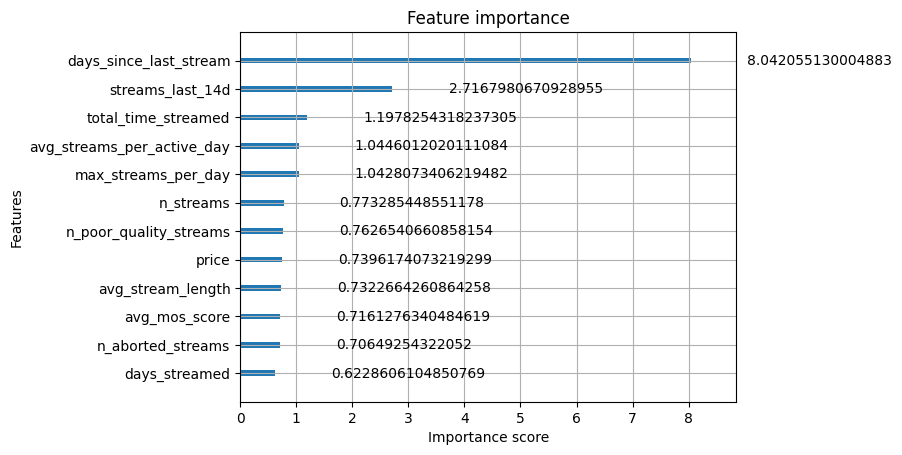

In [336]:
xgb.plot_importance(best_model, importance_type="gain")
plt.show()

In [337]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Separate your features (X) and target (y) from the test set
X_test = test_df.drop("churned")
y_test = test_df['churned']

# 2. Generate hard predictions (0 or 1)
y_pred = best_model.predict(X_test)

# 3. Generate probability predictions (0.0 to 1.0) 
# We slice [:, 1] to get the probability of the positive class (Churned = 1)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 4. Print the evaluation metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}\n")

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.61      0.73        61
           1       0.60      0.92      0.73        39

    accuracy                           0.73       100
   macro avg       0.76      0.76      0.73       100
weighted avg       0.80      0.73      0.73       100

ROC-AUC Score: 0.8058

--- Confusion Matrix ---
[[37 24]
 [ 3 36]]
